Data Science Internship Level 2 Task 1 


In [55]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import sympy  
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error ,r2_score
from sklearn.preprocessing import LabelEncoder 
new = pd.read_csv("Dataset .csv")
data = pd.DataFrame(new)
data.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [56]:
Restaurant = len(data['Restaurant Name'])
print(Restaurant)

4411


In [57]:
x = data[data['Has Table booking'] == "Yes"]
x = len(x)
y = data[data['Has Online delivery'] == "Yes"]
y = len(y)
offer = len(data['Has Table booking'])
delivery = len(data['Has Online delivery'])
total_offer = x/offer*Restaurant
total_delivery = y/delivery*Restaurant
print("total number of offer",x)
print("total number of delivery",y)
print("total percentage of booking",total_offer)
print("total percentage of delib=very",total_delivery)


total number of offer 625
total number of delivery 1163
total percentage of booking 625.0
total percentage of delib=very 1163.0


In [58]:
avrg = data.groupby('Has Table booking')['Aggregate rating'].mean()
print(avrg)

Has Table booking
No     2.884941
Yes    3.551200
Name: Aggregate rating, dtype: float64


In [59]:
#rice = data['Has Online delivery'] 
lon = len(data['Has Online delivery'].map({'Yes':1,'No':0}))
price_delivery = data.groupby('Price range').mean(lon)
print("deliveryamong restaurants with different price ranges",price_delivery)

deliveryamong restaurants with different price ranges              Restaurant ID  Country Code  Longitude   Latitude  \
Price range                                                      
1.0           1.023400e+07     18.063953  59.260696  27.184308   
2.0           8.859443e+06     26.350796  54.943959  26.412210   
3.0           7.785886e+06     39.164368  51.169691  24.766498   
4.0           6.441520e+06     48.134615  48.905946  19.256341   

             Average Cost for two  Aggregate rating       Votes  
Price range                                                      
1.0                    265.074419          2.307849   70.388953  
2.0                    540.872016          3.110743  196.148541  
3.0                   1038.580460          3.754483  521.490805  
4.0                   1713.990385          3.884936  464.352564  


In [60]:
price_range = data['Price range'].mode()[0]
print(f"common price range:{price_range}")


common price range:1.0


In [61]:
average_rate = data.groupby('Aggregate rating')['Price range'].mean().round(2)
print("Calculate the average rating for each price range",average_rate)

Calculate the average rating for each price range Aggregate rating
0.0    1.28
1.8    3.00
1.9    1.00
2.0    1.00
2.1    2.25
2.2    1.69
2.3    1.86
2.4    1.92
2.5    1.80
2.6    1.85
2.7    1.80
2.8    1.56
2.9    1.49
3.0    1.55
3.1    1.51
3.2    1.78
3.3    1.86
3.4    1.95
3.5    2.10
3.6    2.02
3.7    2.14
3.8    2.29
3.9    2.41
4.0    2.61
4.1    2.41
4.2    2.56
4.3    2.46
4.4    2.79
4.5    2.47
4.6    2.67
4.7    2.85
4.8    3.16
4.9    2.79
Name: Price range, dtype: float64


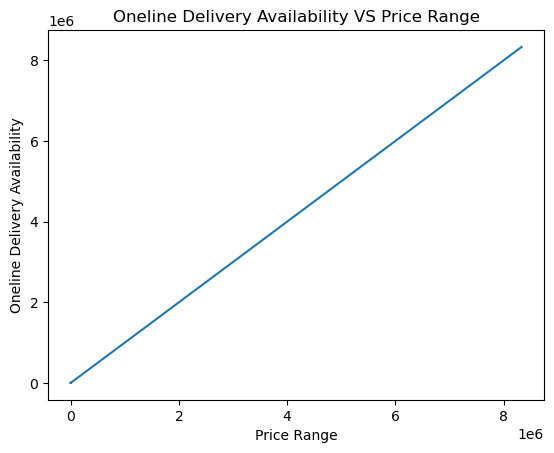

In [62]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
t = price_delivery.mean()
r = price_delivery.mean()
plt.plot(t,r)
plt.ylabel("Oneline Delivery Availability")
plt.xlabel("Price Range")
plt.title("Oneline Delivery Availability VS Price Range")
plt.show()



Data science Level 2 Task 2 

In [63]:
data['Aggregate rating'] = data['Aggregate rating']+np.random.normal(0,0.2 , len(data))
print("\n=== Price Range Analysis ===")
print(data['Aggregate rating'].head())



=== Price Range Analysis ===
0    4.840138
1    4.594406
2    4.259737
3    4.655163
4    5.101885
Name: Aggregate rating, dtype: float64


In [64]:
most_price = data['Price range'].mode()[0]
print(f"Most Comman Price Range:{most_price}")


Most Comman Price Range:1.0


In [65]:
avr_rate = data.groupby('Price range')['Aggregate rating'].mean().reset_index()
print("\nAverage Rating By Price Range:")
print(avr_rate)


Average Rating By Price Range:
   Price range  Aggregate rating
0          1.0          2.302099
1          2.0          3.115570
2          3.0          3.749163
3          4.0          3.882871


In [32]:
color_rat = data.groupby(['Price range','Rating color'])['Aggregate rating'].mean().reset_index()
heighest_color = color_rat.loc[color_rat.groupby('Price range')['Aggregate rating'].idxmax()]
wow = ['color with highest average for each price range']
print("\n COLOR WITH HIGHEST AVERAGE FOR EACH PRICE RANGE")#f"{wow.upper()})
print(heighest_color[['Price range','Rating color','Aggregate rating']])


 COLOR WITH HIGHEST AVERAGE FOR EACH PRICE RANGE
    Price range Rating color  Aggregate rating
0           1.0   Dark Green          4.695878
6           2.0   Dark Green          4.613077
12          3.0   Dark Green          4.644129
18          4.0   Dark Green          4.790717


C:\Users\visha\AppData\Local\Temp\ipykernel_8600\1002810592.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x = 'Price range',y = 'Aggregate rating',hue = 'Rating color',data = data ,ci= None)


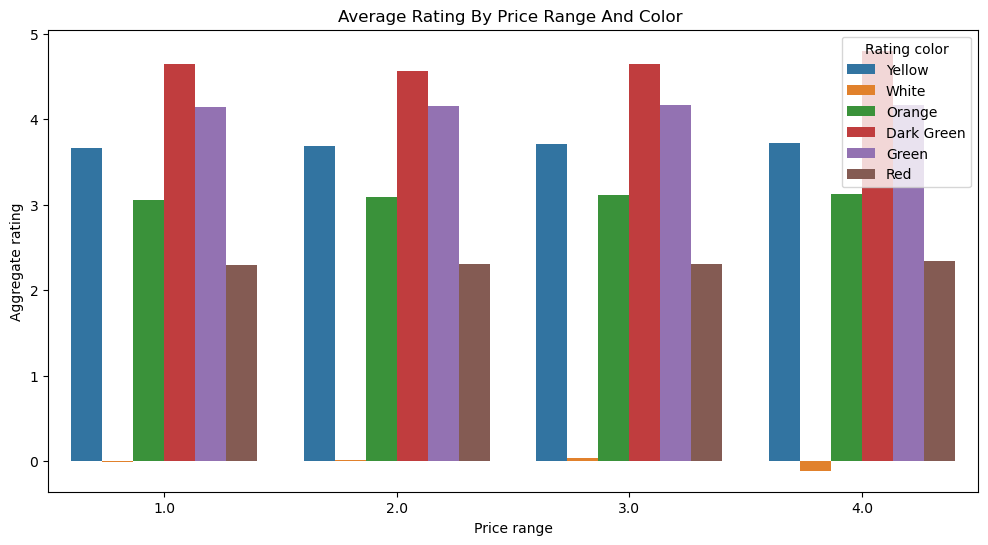

In [66]:
plt.figure(figsize = (12,6))
sns.barplot(x = 'Price range',y = 'Aggregate rating',hue = 'Rating color',data = data ,ci= None)
plt.title('Average Rating By Price Range And Color ')
plt.show()


Data Science Internship Level 2 Task 3

In [67]:

data['Restaurant_Names'] = data['Restaurant Name'].astype(str).apply(len)
data['Address_of'] = data['Address'].astype(str).apply(len)
print(f"\n Restaurant name{data['Restaurant_Names'].head()}")
print(f"\n Restaurant Address{data['Address_of'].head()}")




 Restaurant name0    16
1    16
2    22
3     4
4    11
Name: Restaurant_Names, dtype: int64

 Restaurant Address0    71
1    67
2    56
3    70
4    64
Name: Address_of, dtype: int64


In [53]:
data.head(2)
data['Has_Table_of'] = data['Has Table booking'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0 )
data['Has_Online_of'] = data['Has Online delivery'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0 )
print(data['Has_Table_of'].head())
print(data['Has_Online_of'].head())

0    0
1    0
2    0
3    0
4    0
Name: Has_Table_of, dtype: int64
0    0
1    0
2    0
3    0
4    0
Name: Has_Online_of, dtype: int64
